#import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd


# Load Dataset

In [ ]:
path = '<your path>'
test_df=pd.read_csv(path+'test_df_ori.csv')
train_df = pd.read_csv(path+'train_df_synt.csv')
valid_df = pd.read_csv(path+'valid_df_synt.csv')

In [ ]:
test_df.groupby('relationship').count()

,Unnamed: 0,id,year,input_x,id2,year2,input_y,relationship_v2,penjelasan
relationship,,,,,,,,,
equivalent,1916,1916,1916,1916,1916,1916,1916,1916,1916
lebih khusus dari,444,444,444,444,444,444,444,444,444
lebih umum dari,444,444,444,444,444,444,444,444,444
tidak ada hubungan,2804,2804,2804,2804,2804,2804,2804,2804,2804


In [ ]:
maprelationship = {
    'equivalent': 'equivalen',
    'lebih umum dari': 'lebih agregat',
    'lebih khusus dari': 'lebih detail',
    'tidak ada hubungan': 'tidak ada hubungan'
}
test_df['relationship'] = test_df['relationship'].map(maprelationship)
train_df['relationship'] = train_df['relationship'].map(maprelationship)
valid_df['relationship'] = valid_df['relationship'].map(maprelationship)

In [ ]:
from re import X
def upper(X):
  return X.upper()
test_df['relationship'] = test_df['relationship'].apply(upper)
train_df['relationship'] = train_df['relationship'].apply(upper)
valid_df['relationship'] = valid_df['relationship'].apply(upper)

In [ ]:
test_df.groupby('relationship').count()

,Unnamed: 0,id,year,input_x,id2,year2,input_y,relationship_v2,penjelasan
relationship,,,,,,,,,
EQUIVALEN,1916,1916,1916,1916,1916,1916,1916,1916,1916
LEBIH AGREGAT,444,444,444,444,444,444,444,444,444
LEBIH DETAIL,444,444,444,444,444,444,444,444,444
TIDAK ADA HUBUNGAN,2804,2804,2804,2804,2804,2804,2804,2804,2804


#TRAIN CLASSIFIER

##import

In [ ]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.5 MB/s eta 0:00:00


In [ ]:
import os, json, random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BitsAndBytesConfig,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt


## Reproducibility and config

In [ ]:


# ----------------------------
# 0) Reproducibility
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------
# 1) Config
# ----------------------------
MODEL_NAME = "meta-llama/Llama-3.2-3B-Instruct"  # ganti sesuai model Anda
OUTPUT_ROOT = "folder output"

label2id = {"EQUIVALEN": 0, "LEBIH AGREGAT": 1, "LEBIH DETAIL": 2, "TIDAK ADA HUBUNGAN": 3}
id2label = {v: k for k, v in label2id.items()}
label_order = [id2label[i] for i in range(len(id2label))]

# Instruction template (untuk cara 3)
INSTRUCTION_TEXT = ("""
  Anda adalah seorang ahli bahasa yang ditugaskan untuk mengidentifikasi hubungan semantik antara dua teks.
  Tentukan hubungan semantik dari dua teks yang diberikan. Pilih satu dari hubungan berikut:
  - EQUIVALEN - jika informasi pada teks A sama atau mirip dengan informasi pada teks B.
  - LEBIH AGREGAT - jika informasi teks A dapat diagregatkan dari informasi teks B.
  - LEBIH DETAIL - jika informasi teks B dapat diagregatkan dari informasi teks A.
  - TIDAK ADA HUBUNGAN - jika informasi pada teks A tidak berhubungan dengan informasi pada teks B.
"""
)

# Training hyperparams (detail bisa Anda pindahkan ke section terpisah di paper)
MAX_LEN = 512
BATCH_SIZE = 4
GRAD_ACC = 8
EPOCHS = 3
LR = 2e-4
LOG_STEPS = 50

## Tokenizer + Quant config && Dataset helpers

In [ ]:



# ----------------------------
# 2) Tokenizer + Quant config
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
compute_dtype = torch.bfloat16 if use_bf16 else (torch.float16 if torch.cuda.is_available() else torch.float32)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

collator = DataCollatorWithPadding(tokenizer=tokenizer)


# ----------------------------
# 3) Dataset helpers
# ----------------------------
def to_hf_dataset(df: pd.DataFrame) -> Dataset:
    # Pastikan hanya kolom yang dipakai
    return Dataset.from_pandas(df[["input_x", "input_y", "relationship"]])

def tokenize_pair_no_instruction(ex):
    # Cara 1: pair input langsung (tanpa instruction)
    enc = tokenizer(
        ex["input_x"], ex["input_y"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )
    enc["labels"] = label2id[ex["relationship"]]
    return enc

def tokenize_pair_no_instruction(ex):
    # Cara 1: pair input langsung (tanpa instruction)
    enc = tokenizer(
        ex["input_x"], ex["input_y"],
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )
    enc["labels"] = label2id[ex["relationship"]]
    return enc

def tokenize_pair_no_instruction_2(ex):
    # Cara 3: input tidak diberi instruction, tetap sequence classification (bukan generative)
    text = (f'''<s>{ex['input_x']}</s><s>{ex['input_y']}</s>''')
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )
    enc["labels"] = label2id[ex["relationship"]]
    return enc

def tokenize_pair_with_instruction(ex):
    # Cara 3: input diberi instruction, tetap sequence classification (bukan generative)
    text = (f'''
         <|begin_of_text|>
          <|start_header_id|>system<|end_header_id|>
          {INSTRUCTION}
          <|eot_id|>
          <|start_header_id|>user<|end_header_id|>
          Teks A: "{ex['input_x']}"
          Teks B: "{ex['input_y']}"

          Apa hubungan semantik antara Teks A dan Teks B?
          Jawablah dengan salah satu pilihan berikut: "EQUIVALEN", "LEBIH AGREGAT", "LEBIH DETAIL" atau "TIDAK ADA HUBUNGAN".
          Jawab HANYA nama hubungan. Jangan tambahkan teks atau penjelasan lain.
          Berikan output dalam format JSON:{{"hubungan": "..."}}
          <|eot_id|>
          <|start_header_id|>assistant<|end_header_id|><|eot_id|>'''
    )
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LEN,
        padding=False
    )
    enc["labels"] = label2id[ex["relationship"]]
    return enc


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

##model builder

In [ ]:


# ----------------------------
# 4) Model builder (QLoRA + LoRA)
# ----------------------------
def build_model():
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=4,
        id2label=id2label,
        label2id=label2id,
        quantization_config=bnb_config,
        device_map="auto",
    )
    base.config.pad_token_id = tokenizer.pad_token_id
    base.config.use_cache = False

    base = prepare_model_for_kbit_training(base)

    # memastikan classification head ikut tersimpan
    head_name = None
    if hasattr(base, "score"):
        head_name = "score"
    elif hasattr(base, "classifier"):
        head_name = "classifier"

    lora_cfg = LoraConfig(
        r=32,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type=TaskType.SEQ_CLS,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
        modules_to_save=[head_name] if head_name is not None else None,
    )

    model = get_peft_model(base, lora_cfg)
    return model

##metrics

In [ ]:



# ----------------------------
# 5) Metrics during training (optional)
# ----------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": classification_report(labels, preds, output_dict=True, zero_division=0)["macro avg"]["f1-score"],
    }


##Evaluation + Saving outputs

In [ ]:


# ----------------------------
# 6) Evaluation + Saving outputs
# ----------------------------
def save_evaluation_outputs(out_dir, raw_test_df, logits, y_true):
    os.makedirs(out_dir, exist_ok=True)

    # Pred labels + probs
    probs = torch.softmax(torch.tensor(logits), dim=-1).cpu().numpy()
    pred_ids = probs.argmax(axis=1)
    y_pred = pred_ids

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(label_order))))
    cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
    cm_path = os.path.join(out_dir, "confusion_matrix.csv")
    cm_df.to_csv(cm_path, index=True)

    # Plot CM (PNG)
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(len(label_order))
    plt.xticks(tick_marks, label_order, rotation=45, ha="right")
    plt.yticks(tick_marks, label_order)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "confusion_matrix.png"), dpi=200)
    plt.close()

    # Classification report (per class + macro avg + weighted avg + accuracy)
    report = classification_report(
        y_true, y_pred,
        labels=list(range(len(label_order))),
        target_names=label_order,
        output_dict=True,
        zero_division=0
    )
    # Tambahkan juga accuracy eksplisit (report sudah punya "accuracy", tapi kita pastikan)
    report["accuracy_explicit"] = float(accuracy_score(y_true, y_pred))

    with open(os.path.join(out_dir, "classification_report.json"), "w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)

    # Predictions file (CSV)
    pred_df = raw_test_df.copy().reset_index(drop=True)
    pred_df["true_id"] = y_true
    pred_df["true_label"] = [id2label[i] for i in y_true]
    pred_df["pred_id"] = y_pred
    pred_df["pred_label"] = [id2label[i] for i in y_pred]
    for i, lab in enumerate(label_order):
        pred_df[f"prob_{lab}"] = probs[:, i]
    pred_df.to_csv(os.path.join(out_dir, "predictions.csv"), index=False)

    # Summary metrics (ringkas)
    summary = {
        "accuracy": float(report["accuracy"]),
        "macro_precision": float(report["macro avg"]["precision"]),
        "macro_recall": float(report["macro avg"]["recall"]),
        "macro_f1": float(report["macro avg"]["f1-score"]),
        "weighted_precision": float(report["weighted avg"]["precision"]),
        "weighted_recall": float(report["weighted avg"]["recall"]),
        "weighted_f1": float(report["weighted avg"]["f1-score"]),
    }

    # tambahkan precision/recall/f1 untuk setiap kelas
    for lab in label_order:  # ["EQUIVALEN","LEBIH AGREGAT","LEBIH DETAIL","TIDAK ADA HUBUNGAN"]
        key = lab.lower().replace(" ", "_")  # mis: "lebih_agregat"
        summary[f"{key}_precision"] = float(report[lab]["precision"])
        summary[f"{key}_recall"] = float(report[lab]["recall"])
        summary[f"{key}_f1"] = float(report[lab]["f1-score"])
        summary[f"{key}_support"] = float(report[lab]["support"])  # opsional tapi biasanya berguna

    with open(os.path.join(out_dir, "eval_metrics.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)


##Train + Eval runner

In [ ]:


# ----------------------------
# 7) Train + Eval runner
# ----------------------------
def run_experiment(mode_name, tokenize_fn):
    out_dir = os.path.join(OUTPUT_ROOT, mode_name)
    os.makedirs(out_dir, exist_ok=True)

    # Save run config for reproducibility
    run_info = {
        "mode": mode_name,
        "model_name": MODEL_NAME,
        "seed": SEED,
        "max_length": MAX_LEN,
        "label2id": label2id,
        "train_hparams": {
            "batch_size": BATCH_SIZE,
            "grad_accum": GRAD_ACC,
            "epochs": EPOCHS,
            "learning_rate": LR,
            "bf16": bool(use_bf16),
        },
        "instruction_used": (mode_name == "with_instruction"),
    }
    if mode_name == "with_instruction":
        run_info["instruction_text"] = INSTRUCTION_TEXT

    with open(os.path.join(out_dir, "run_info.json"), "w", encoding="utf-8") as f:
        json.dump(run_info, f, ensure_ascii=False, indent=2)

    # Build datasets
    train_ds = to_hf_dataset(train_df).map(tokenize_fn, remove_columns=["input_x","input_y","relationship"])
    valid_ds = to_hf_dataset(valid_df).map(tokenize_fn, remove_columns=["input_x","input_y","relationship"])
    test_raw = test_df[["input_x","input_y","relationship"]].copy()
    test_ds = to_hf_dataset(test_raw).map(tokenize_fn, remove_columns=["input_x","input_y","relationship"])

    # Build model
    model = build_model()

    # Training args
    args = TrainingArguments(
        output_dir=out_dir,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACC,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        logging_steps=LOG_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        bf16=use_bf16,
        fp16=(torch.cuda.is_available() and not use_bf16),
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        data_collator=collator,
        compute_metrics=compute_metrics,
    )

    # Train
    trainer.train()

    # Save model artifacts (adapter + tokenizer + label mapping)
    # - Untuk PEFT/LoRA, ini menyimpan adapter weights + config
    trainer.save_model(out_dir)  # saves model (adapter) to out_dir
    tokenizer.save_pretrained(out_dir)

    # Evaluate on test set (gold) + save all outputs
    pred_out = trainer.predict(test_ds)
    logits = pred_out.predictions
    y_true = pred_out.label_ids

    save_evaluation_outputs(out_dir, test_raw.reset_index(drop=True), logits, y_true)

    print(f"[DONE] {mode_name} saved to: {out_dir}")


##run

In [ ]:
 = to_hf_dataset(train_df).map(tokenize_pair_no_instruction, remove_columns=["input_x","input_y","relationship"])

Map:   0%|          | 0/4486 [00:00<?, ? examples/s]

Column([[128000, 34277, 62031, 29, 735, 797, 10574, 276, 52618, 2850, 34801, 5697, 39472, 3026, 39172, 391, 8826, 603, 13856, 694, 39245, 74, 1822, 77468, 25041, 276, 29, 5345, 64, 453, 46488, 8791, 3105, 320, 45, 39200, 8, 20166, 52618, 2850, 34801, 5697, 39472, 1871, 32390, 68821, 8826, 603, 13856, 30, 694, 77468, 25041, 276, 29, 128000, 34277, 62031, 29, 31701, 10426, 24218, 372, 40633, 268, 694, 39245, 74, 1822, 77468, 25041, 276, 29, 14569, 97308, 10785, 85174, 694, 77468, 25041, 276, 29], [128000, 34277, 62031, 29, 735, 797, 10574, 276, 52618, 2850, 1069, 76018, 276, 9279, 1871, 32390, 68821, 8826, 603, 13856, 694, 39245, 74, 1822, 77468, 25041, 276, 29, 622, 11755, 88730, 4596, 5869, 675, 22026, 34801, 5697, 11, 1469, 77527, 320, 45, 39200, 8, 84571, 59654, 4596, 296, 93782, 30, 694, 77468, 25041, 276, 29, 128000, 34277, 62031, 29, 31701, 10426, 40633, 268, 694, 39245, 74, 1822, 77468, 25041, 276, 29, 5345, 77527, 40238, 52465, 17225, 2024, 2808, 266, 30892, 12077, 266, 57988, 1

In [ ]:


# ----------------------------
# 8) Run both modes (Cara 1 & Cara 3)
# ----------------------------
run_experiment("no_instruction", tokenize_pair_no_instruction)
# run_experiment("no_instruction_2", tokenize_pair_no_instruction_2)



Map:   0%|          | 0/4486 [00:00<?, ? examples/s]

Map:   0%|          | 0/1122 [00:00<?, ? examples/s]

Map:   0%|          | 0/5608 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Llama-3.2-3B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.960500,0.235605,0.926025,0.861526
2,0.661200,0.193864,0.971480,0.949018
3,0.461200,0.187684,0.971480,0.945231


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


[DONE] no_instruction_2 saved to: /content/drive/MyDrive/_Lutfi/_Course/Material/Research/_20 finetune/Meta-Llama-3-8B-Instruct/TRY other code/#1 80 20 100 as encoding-based model/no_instruction_2


In [ ]:
# run_experiment("with_instruction", tokenize_pair_with_instruction)

# Rule Based Final Prediction

In [ ]:
path ='your path'
# save_dir = path+ "no_instruction_2/"
save_dir = path+ "no_instruction/"



In [ ]:
import os
name = ""
test_df_inference1 = pd.read_csv(save_dir+'predictions.csv')

test_df_inference1.head()

,input_x,input_y,relationship,true_id,true_label,pred_id,pred_label,prob_EQUIVALEN,prob_LEBIH AGREGAT,prob_LEBIH DETAIL,prob_TIDAK ADA HUBUNGAN
0,<blok> Pengenalan tempat </blok><pertanyaan> P...,<blok> Pengenalan tempat </blok><pertanyaan> P...,EQUIVALEN,0,EQUIVALEN,0,EQUIVALEN,0.999750,1.873411e-06,1.653279e-06,0.000246
1,<blok> Pengenalan tempat </blok><pertanyaan> K...,<blok> Pengenalan tempat </blok><pertanyaan> K...,EQUIVALEN,0,EQUIVALEN,0,EQUIVALEN,0.999861,2.784884e-07,4.051983e-07,0.000139
2,<blok> Pengenalan tempat </blok><pertanyaan> K...,<blok> Pengenalan tempat </blok><pertanyaan> K...,EQUIVALEN,0,EQUIVALEN,0,EQUIVALEN,0.999546,1.652942e-06,7.109215e-07,0.000451
3,<blok> Keterangan anggota rumah tangga </blok>...,<blok> Keterangan anggota rumah tangga </blok>...,EQUIVALEN,0,EQUIVALEN,0,EQUIVALEN,0.999879,6.680713e-07,5.538505e-07,0.000120
4,<blok> Keterangan anggota rumah tangga </blok>...,<blok> Keterangan anggota rumah tangga </blok>...,EQUIVALEN,0,EQUIVALEN,0,EQUIVALEN,0.999745,7.110631e-07,7.336348e-07,0.000253


In [ ]:
test_df_infer = test_df.copy()
test_df_infer['input_x_2'] = test_df_inference1['input_x']
test_df_infer['input_y_2'] = test_df_inference1['input_y']
test_df_infer['pred_label'] = test_df_inference1['pred_label'].apply(upper)


In [ ]:
test_df_infer[(test_df_infer['relationship']!=test_df_infer['pred_label'])].sort_values('relationship')

,Unnamed: 0,id,year,input_x,id2,year2,input_y,relationship,relationship_v2,penjelasan,input_x_2,input_y_2,pred_label
141,141,2010-B5P6B,2010,<blok> Kegiatan seminggu yang lalu </blok><per...,2017-b5_r26a,2017,<blok> Pekerjaan utama </blok><pertanyaan> Dal...,EQUIVALEN,equivalen,karena keduanya mempunyai arti semantik yang sama,<blok> Kegiatan seminggu yang lalu </blok><per...,<blok> Pekerjaan utama </blok><pertanyaan> Dal...,LEBIH AGREGAT
2211,817,2012-B5P21A- 3,2012,<blok> Kegiatan mencari pekerjaan/mempersiapka...,2015-B5_R21A-3,2015,<blok> Kegiatan mencari pekerjaan/mempersiapka...,EQUIVALEN,equivalen,karena keduanya mempunyai arti semantik yang sama,<blok> Kegiatan mencari pekerjaan/mempersiapka...,<blok> Kegiatan mencari pekerjaan/mempersiapka...,TIDAK ADA HUBUNGAN
2191,797,2012-B5P19- 7,2012,<blok> Kegiatan mencari pekerjaan/mempersiapka...,2015-B5_R19-7,2015,<blok> Kegiatan mencari pekerjaan/mempersiapka...,EQUIVALEN,equivalen,karena keduanya mempunyai arti semantik yang sama,<blok> Kegiatan mencari pekerjaan/mempersiapka...,<blok> Kegiatan mencari pekerjaan/mempersiapka...,LEBIH AGREGAT
2088,694,2012-B5P16B- 4,2012,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,2015-B5_R16B-4,2015,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,EQUIVALEN,equivalen,karena keduanya mempunyai arti semantik yang sama,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,TIDAK ADA HUBUNGAN
2087,693,2012-B5P16B- 3,2012,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,2015-B5_R16B-3,2015,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,EQUIVALEN,equivalen,karena keduanya mempunyai arti semantik yang sama,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,<blok> Pekerjaan utama </blok><pertanyaan> Ber...,TIDAK ADA HUBUNGAN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,1144,2015-B5_R1C,2015,<blok> Pendidikan </blok><pertanyaan> Apakah (...,2015-B5_R1C,2015,<blok> Pendidikan </blok><pertanyaan> Apakah (...,TIDAK ADA HUBUNGAN,tidak ada hubungan,kedua pertanyaan tersebut tidak berkaitan atau...,<blok> Pendidikan </blok><pertanyaan> Apakah (...,<blok> Pendidikan </blok><pertanyaan> Apakah (...,EQUIVALEN
1013,1013,2017-b4_k8,2017,<blok> Keterangan anggota rumah tangga </blok>...,2012-STATK,2012,<blok> Keterangan anggota rumah tangga </blok>...,TIDAK ADA HUBUNGAN,tidak ada hubungan,kedua pertanyaan tersebut tidak berkaitan atau...,<blok> Keterangan anggota rumah tangga </blok>...,<blok> Keterangan anggota rumah tangga </blok>...,EQUIVALEN
939,939,2012-B5P20_3,2012,<blok> Kegiatan mencari pekerjaan/mempersiapka...,2017-b5_r19i,2017,<blok> Kegiatan mencari pekerjaan/mempersiapka...,TIDAK ADA HUBUNGAN,tidak ada hubungan,kedua pertanyaan tersebut tidak berkaitan atau...,<blok> Kegiatan mencari pekerjaan/mempersiapka...,<blok> Kegiatan mencari pekerjaan/mempersiapka...,LEBIH DETAIL
3939,2545,2015-B5_R25-3,2015,<blok> Pengalaman kerja </blok><pertanyaan> Al...,2020-r30a-9,2020,<blok> Pengalaman kerja </blok><pertanyaan> Ap...,TIDAK ADA HUBUNGAN,tidak ada hubungan,kedua kategori tersebut tidak berkaitan atau b...,<blok> Pengalaman kerja </blok><pertanyaan> Al...,<blok> Pengalaman kerja </blok><pertanyaan> Ap...,LEBIH DETAIL


In [ ]:
test_df_infer['pred_label'].isna().sum()

np.int64(0)

In [ ]:
input_x = test_df_infer[['id', 'input_x']]
input_y = test_df_infer[['id2', 'input_y']]

In [ ]:
input_x_unique = input_x.drop_duplicates()
input_y_unique = input_y.drop_duplicates()

In [ ]:
test_df_infer['predicted_label_re'] = None

In [ ]:
import numpy as np

# pastikan kolom ada
if "predicted_label_re" not in test_df_infer.columns:
    test_df_infer["predicted_label_re"] = np.nan

def resolve_label(labels_unique):
    """labels_unique: array/list unique labels (exclude TIDAK ADA HUBUNGAN already)"""
    flag = 0
    if "LEBIH AGREGAT" in labels_unique:
        flag = flag + 1
    if "LEBIH DETAIL" in labels_unique:
        flag = flag + 1
    if flag <2:
        if "LEBIH AGREGAT" in labels_unique:
            # aturan Anda: jika ada EQUIVALEN -> menjadi LEBIH AGREGAT
            return "LEBIH AGREGAT"
        elif "LEBIH DETAIL" in labels_unique:
            return "LEBIH DETAIL"
        else:
          return "LEBIH AGREGAT"
    else:
        return None

# ---------- INPUT_X: per YEAR ----------
for _, row in input_x_unique.iterrows():
    id_ = row["id"]
    input_x = row["input_x"]

    base_mask = (
        (test_df_infer["id"] == id_) &
        (test_df_infer["input_x"] == input_x) &
        (test_df_infer["pred_label"] != "TIDAK ADA HUBUNGAN")
    )

    # group by year
    for year_val, idx in test_df_infer.loc[base_mask].groupby("year2").groups.items():
        rels = test_df_infer.loc[idx, "pred_label"].unique()
        if len(rels) > 1:
            print("\n")
            for i in test_df_infer.loc[idx, 'input_y']:
                print(i)

            # print(rels)
            pred_re = resolve_label(rels)
            test_df_infer.loc[idx, "predicted_label_re"] = pred_re
            print("X |", id_, "|", year_val, "|", input_x, "=>", rels, "->", pred_re)

print("\n****************************\n")


# ---------- INPUT_Y: per YEAR ----------
for _, row in input_y_unique.iterrows():
    id2_ = row["id2"]
    input_y = row["input_y"]

    base_mask = (
        (test_df_infer["id2"] == id2_) &
        (test_df_infer["input_y"] == input_y) &
        (test_df_infer["pred_label"] != "TIDAK ADA HUBUNGAN")
    )

    for year_val, idx in test_df_infer.loc[base_mask].groupby("year").groups.items():
        rels = test_df_infer.loc[idx, "pred_label"].unique()
        if len(rels) > 1:
            print("\n")
            for i in test_df_infer.loc[idx, 'input_x']:
                print(i)
            pred_re = resolve_label(rels)
            test_df_infer.loc[idx, "predicted_label_re"] = pred_re
            print("Y |", id2_, "|", year_val, "|", input_y, "=>", rels, "->", pred_re)

# fallback: yang belum terisi pakai pred_label asli
test_df_infer["predicted_label_re"] = test_df_infer["predicted_label_re"].fillna(test_df_infer["pred_label"])



<blok> Pekerjaan utama </blok><pertanyaan> JIKA R.27.a = 1, 5 atau 6, berapakah pendapatan/penghasilan bersih yang diterima (NAMA) selama sebulan yang lalu dari pekerjaan utama? (uang) </pertanyaan>
<blok> Pekerjaan utama </blok><pertanyaan> JIKA R.27.a = 4, berapakah upah/gaji bersih (NAMA) selama sebulan yang lalu dari pekerjaan utama? (uang) </pertanyaan>
<blok> Pekerjaan utama </blok><pertanyaan> Upah Lembur, Uang Transportasi dan Uang Makan: (uang) </pertanyaan>
X | 2012-B5P13A | 2017 | <blok> Pekerjaan utama </blok><pertanyaan> Berapakah upah/gaji bersih yang diterima (NAMA) selama sebulan yang lalu dari pekerjaan utama? (berupa Uang)  </pertanyaan> => ['EQUIVALEN' 'LEBIH AGREGAT'] -> LEBIH AGREGAT


<blok> Pekerjaan utama </blok><pertanyaan> JIKA R.27.a = 1, 5 atau 6, berapakah pendapatan/ penghasilan bersih yang diterima (NAMA) selama sebulan yang lalu dari pekerjaan utama? (barang) </pertanyaan>
<blok> Pekerjaan utama </blok><pertanyaan> JIKA R.27.a = 4, berapakah upah/gaji 

In [ ]:
import os
# test_df_infer.to_csv(os.path.join(save_dir, 'test_predictions_clean_reclass.csv'))
test_df_infer.to_csv(os.path.join(save_dir, name+'_test_predictions_clean_reclass.csv'))

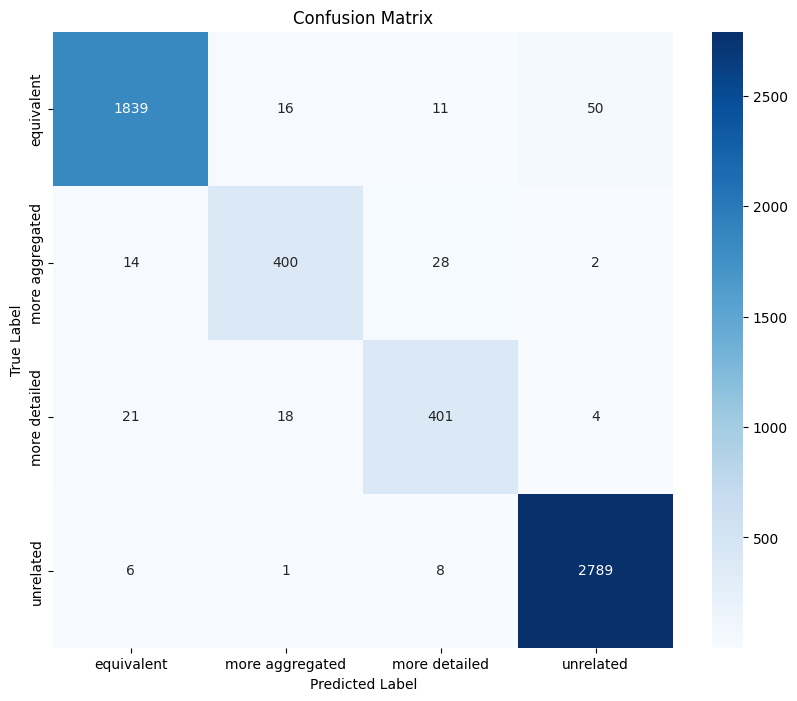

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure `predicted_label_v2` column is filled for all rows for consistent evaluation
# test_df_inference1['predicted_label_v2'] = test_df_inference1['predicted_label_v2'].fillna('UNKNOWN_GENERATION')

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['pred_label'].tolist()

# Get unique labels to ensure consistent order in matrix
labels_indonesian = sorted(list(set(true_labels + predictions)))

# Create a mapping for Indonesian to English labels
label_mapping = {
    'EQUIVALEN': 'equivalent',
    'LEBIH AGREGAT': 'more aggregated',
    'LEBIH DETAIL': 'more detailed',
    'TIDAK ADA HUBUNGAN': 'unrelated',
    # 'UNKNOWN_GENERATION': 'unknown'
}

# Apply the mapping to the labels
labels_english = [label_mapping.get(label, label) for label in labels_indonesian]

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=labels_indonesian) # Use Indonesian labels for matrix calculation

# Plotting the confusion matrix with English labels
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_english, yticklabels=labels_english)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



Confusion matrix plot saved to: /content/drive/MyDrive/_Lutfi/_Course/Material/Research/_20 finetune/Meta-Llama-3-8B-Instruct/TRY other code/#1 80 20 100 as encoding-based model/no_instruction_2/_confusion_matrix_reclass.png


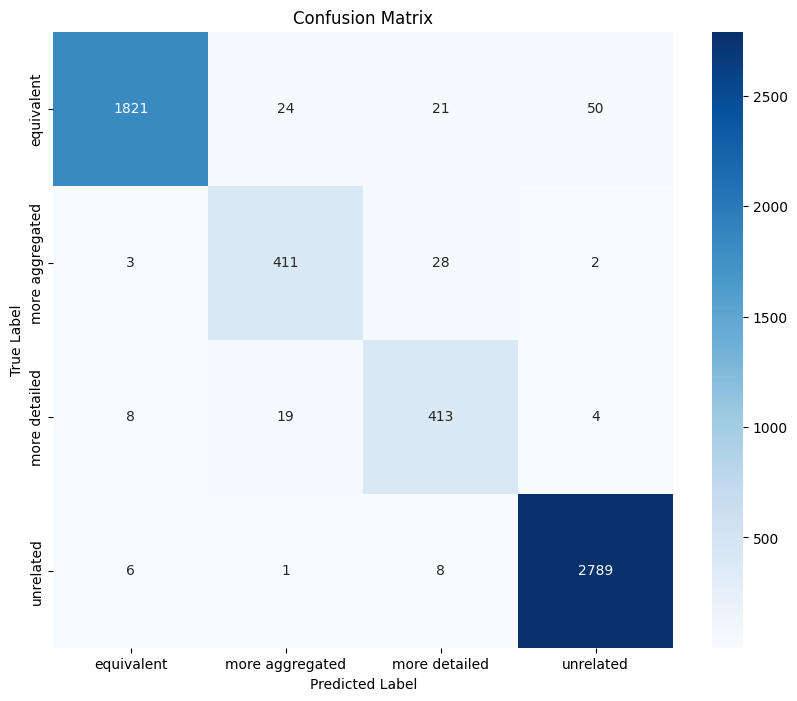

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure `predicted_label_v2` column is filled for all rows for consistent evaluation
# test_df_inference1['predicted_label_v2'] = test_df_inference1['predicted_label_v2'].fillna('UNKNOWN_GENERATION')

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['predicted_label_re'].tolist()

# Get unique labels to ensure consistent order in matrix
labels_indonesian = sorted(list(set(true_labels + predictions)))

# Create a mapping for Indonesian to English labels
label_mapping = {
    'EQUIVALEN': 'equivalent',
    'LEBIH AGREGAT': 'more aggregated',
    'LEBIH DETAIL': 'more detailed',
    'TIDAK ADA HUBUNGAN': 'unrelated',
    # 'UNKNOWN_GENERATION': 'unknown'
}

# Apply the mapping to the labels
labels_english = [label_mapping.get(label, label) for label in labels_indonesian]

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=labels_indonesian) # Use Indonesian labels for matrix calculation

# Plotting the confusion matrix with English labels
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_english, yticklabels=labels_english)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Optionally save the confusion matrix plot
cm_plot_path = os.path.join(save_dir, name+'_confusion_matrix_reclass.png')
plt.savefig(cm_plot_path)
print(f"Confusion matrix plot saved to: {cm_plot_path}")

plt.show()

In [ ]:

pd.DataFrame(cm).to_csv(f"{save_dir}/_{name}_confusion_matrix_reclass.csv")

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import json

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['pred_label'].tolist()

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

# Calculate macro and weighted averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, predictions, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    true_labels, predictions, average='weighted', zero_division=0
)

# Get detailed classification report as a dictionary
full_classification_report = classification_report(true_labels, predictions, output_dict=True, zero_division=0)

print("\n--- Evaluation Results from test_df_inference1 ---")
print(f"Accuracy: {accuracy:.4f}")

print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")

print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

print("\n--- Detailed Classification Report from test_df_inference1 ---")
print(classification_report(true_labels, predictions, zero_division=0))




--- Evaluation Results from test_df_inference1 ---
Accuracy: 0.9681
Precision (Macro): 0.9433
Recall (Macro): 0.9396
F1-Score (Macro): 0.9414
Precision (Weighted): 0.9680
Recall (Weighted): 0.9681
F1-Score (Weighted): 0.9680

--- Detailed Classification Report from test_df_inference1 ---
                    precision    recall  f1-score   support

         EQUIVALEN       0.98      0.96      0.97      1916
     LEBIH AGREGAT       0.92      0.90      0.91       444
      LEBIH DETAIL       0.90      0.90      0.90       444
TIDAK ADA HUBUNGAN       0.98      0.99      0.99      2804

          accuracy                           0.97      5608
         macro avg       0.94      0.94      0.94      5608
      weighted avg       0.97      0.97      0.97      5608



In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import json

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['predicted_label_re'].tolist()

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

# Calculate macro and weighted averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, predictions, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    true_labels, predictions, average='weighted', zero_division=0
)

# Get detailed classification report as a dictionary
full_classification_report = classification_report(true_labels, predictions, output_dict=True, zero_division=0)

print("\n--- Evaluation Results from test_df_inference1 ---")
print(f"Accuracy: {accuracy:.4f}")

print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")

print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

print("\n--- Detailed Classification Report from test_df_inference1 ---")
print(classification_report(true_labels, predictions, zero_division=0))




--- Evaluation Results from test_df_inference1 ---
Accuracy: 0.9690
Precision (Macro): 0.9383
Recall (Macro): 0.9502
F1-Score (Macro): 0.9439
Precision (Weighted): 0.9697
Recall (Weighted): 0.9690
F1-Score (Weighted): 0.9691

--- Detailed Classification Report from test_df_inference1 ---
                    precision    recall  f1-score   support

         EQUIVALEN       0.99      0.95      0.97      1916
     LEBIH AGREGAT       0.90      0.93      0.91       444
      LEBIH DETAIL       0.88      0.93      0.90       444
TIDAK ADA HUBUNGAN       0.98      0.99      0.99      2804

          accuracy                           0.97      5608
         macro avg       0.94      0.95      0.94      5608
      weighted avg       0.97      0.97      0.97      5608



In [ ]:
import os

report_json_path = os.path.join(save_dir, name+'_classification_report_reclass.json')

# Ensure the directory exists
os.makedirs(os.path.dirname(report_json_path), exist_ok=True)

with open(report_json_path, "w") as f:
    json.dump(full_classification_report, f, indent=4)

Confusion matrix plot saved to: /content/drive/MyDrive/_Lutfi/_Course/Material/Research/_20 finetune/Meta-Llama-3-8B-Instruct/TRY other code/#1 80 20 100 as encoding-based model/no_instruction_2/_confusion_matrix.png


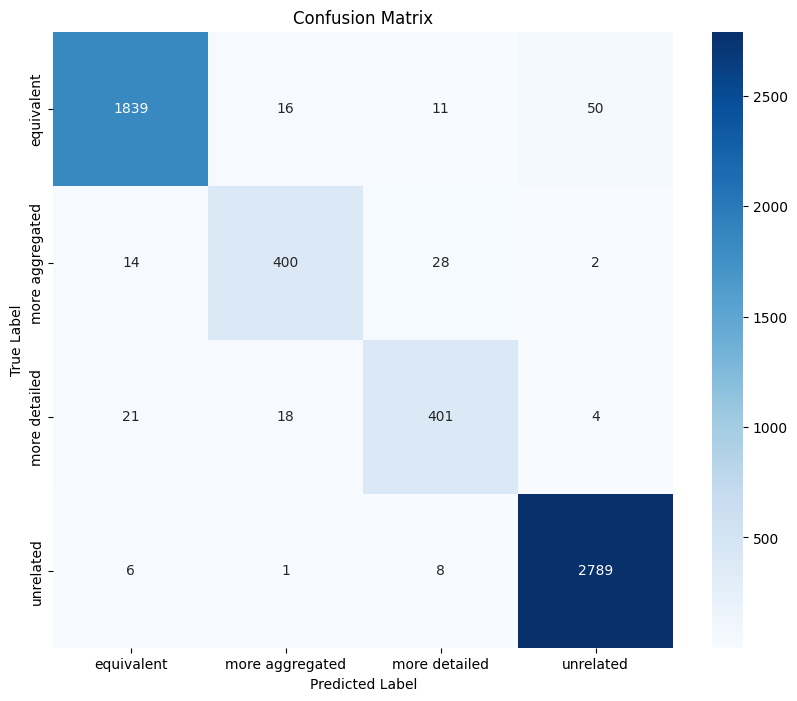


--- Evaluation Results from test_df_inference1 ---
Accuracy: 0.9681
Precision (Macro): 0.9433
Recall (Macro): 0.9396
F1-Score (Macro): 0.9414
Precision (Weighted): 0.9680
Recall (Weighted): 0.9681
F1-Score (Weighted): 0.9680

--- Detailed Classification Report from test_df_inference1 ---
                    precision    recall  f1-score   support

         EQUIVALEN       0.98      0.96      0.97      1916
     LEBIH AGREGAT       0.92      0.90      0.91       444
      LEBIH DETAIL       0.90      0.90      0.90       444
TIDAK ADA HUBUNGAN       0.98      0.99      0.99      2804

          accuracy                           0.97      5608
         macro avg       0.94      0.94      0.94      5608
      weighted avg       0.97      0.97      0.97      5608



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure `predicted_label_v2` column is filled for all rows for consistent evaluation
# test_df_inference1['predicted_label_v2'] = test_df_inference1['predicted_label_v2'].fillna('UNKNOWN_GENERATION')

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['pred_label'].tolist()

# Get unique labels to ensure consistent order in matrix
labels_indonesian = sorted(list(set(true_labels + predictions)))

# Create a mapping for Indonesian to English labels
label_mapping = {
    'EQUIVALEN': 'equivalent',
    'LEBIH AGREGAT': 'more aggregated',
    'LEBIH DETAIL': 'more detailed',
    'TIDAK ADA HUBUNGAN': 'unrelated',
    # 'UNKNOWN_GENERATION': 'unknown'
}

# Apply the mapping to the labels
labels_english = [label_mapping.get(label, label) for label in labels_indonesian]

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=labels_indonesian) # Use Indonesian labels for matrix calculation

# Plotting the confusion matrix with English labels
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_english, yticklabels=labels_english)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Optionally save the confusion matrix plot
cm_plot_path = os.path.join(save_dir, name+'_confusion_matrix.png')
plt.savefig(cm_plot_path)
print(f"Confusion matrix plot saved to: {cm_plot_path}")
plt.show()

pd.DataFrame(cm).to_csv(f"{save_dir}/_{name}_confusion_matrix.csv")
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import json

true_labels = test_df_infer['relationship'].tolist()
predictions = test_df_infer['pred_label'].tolist()

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

# Calculate macro and weighted averages
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    true_labels, predictions, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    true_labels, predictions, average='weighted', zero_division=0
)

# Get detailed classification report as a dictionary
full_classification_report = classification_report(true_labels, predictions, output_dict=True, zero_division=0)

print("\n--- Evaluation Results from test_df_inference1 ---")
print(f"Accuracy: {accuracy:.4f}")

print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")

print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")

print("\n--- Detailed Classification Report from test_df_inference1 ---")
print(classification_report(true_labels, predictions, zero_division=0))

import os

report_json_path = os.path.join(save_dir, name+'_classification_report.json')

# Ensure the directory exists
os.makedirs(os.path.dirname(report_json_path), exist_ok=True)

with open(report_json_path, "w") as f:
    json.dump(full_classification_report, f, indent=4)